<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/10_QAOA_Optimization/QAOA_MaxCut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Combinatorial Optimization: QAOA and Max-Cut

This notebook implements the Quantum Approximate Optimization Algorithm (QAOA) using modern Qiskit 1.0+ Primitives. We apply it to the Max-Cut problem, demonstrating how quantum interference can be parameterized to isolate optimal solutions for NP-Hard routing and logistics problems.

## The Max-Cut Problem

Imagine a network graph with nodes connected by edges. The goal of Max-Cut is to split the nodes into two distinct groups (e.g., Group A and Group B) such that the maximum possible number of edges are "cut" (meaning they connect a node in Group A to a node in Group B). As graphs get larger, calculating every possible combination classically becomes impossible.

## The QAOA Strategy

QAOA tackles this by alternating two quantum operations, controlled by two parameters:

1. **The Cost Hamiltonian (controlled by $\gamma$):** This mathematically represents the edges of our graph. It applies a phase to the quantum state based on how "good" the current cut is.
2. **The Mixer Hamiltonian (controlled by $\beta$):** This applies X-rotations to all qubits, forcing the algorithm to explore the entire landscape of possible solutions rather than getting stuck in a local minimum.

By wrapping these operators in a classical machine-learning loop, we adjust $\gamma$ and $\beta$ until the quantum computer mathematically amplifies the probability of measuring the correct Max-Cut bitstring.

---


In [2]:
!pip install qiskit qiskit-aer matplotlib pylatexenc scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a537c4ec6f652eb7d6fc77b7e9ca6002f87e4b3e24882cec65c1c37b3763e4ac
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initializing QAOA Pipeline for Max-Cut...

Cost Hamiltonian (Graph Edges):
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

Training QAOA circuit parameters (Gamma and Beta)...


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



--- QAOA Results ---
Optimal Parameters [Gamma, Beta]: [3.534 1.178]
Lowest Energy Found: -2.00000


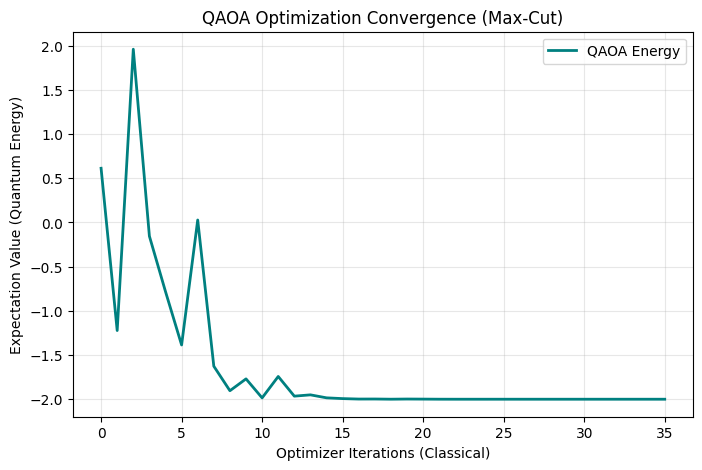


Parameterized QAOA Circuit:


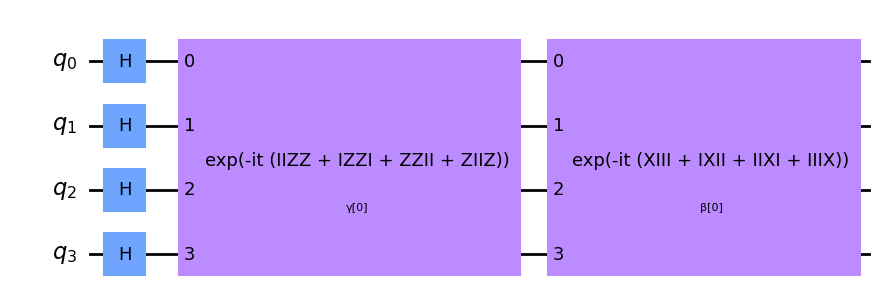

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

def run_qaoa_maxcut():
    """Runs a QAOA optimization for a 4-node Max-Cut problem using Qiskit 1.0+."""
    print("Initializing QAOA Pipeline for Max-Cut...\n")

    # --- 1. Define the Problem (The Cost Hamiltonian) ---
    # We define a 4-node square graph. Edges: (0,1), (1,2), (2,3), (3,0).
    # In the Ising model for Max-Cut, we minimize the sum of Z_i * Z_j for each edge.
    # Qiskit reads right-to-left, so "IIZZ" means Z on qubits 0 and 1.
    pauli_list = [
        ("IIZZ", 1.0), # Edge 0-1
        ("IZZI", 1.0), # Edge 1-2
        ("ZZII", 1.0), # Edge 2-3
        ("ZIIZ", 1.0)  # Edge 3-0
    ]
    cost_hamiltonian = SparsePauliOp.from_list(pauli_list)
    print(f"Cost Hamiltonian (Graph Edges):\n{cost_hamiltonian}\n")

    # --- 2. Build the QAOA Ansatz ---
    # Qiskit's built-in QAOAAnsatz automatically builds the alternating Cost and Mixer layers.
    # reps=1 means we use 1 layer (p=1).
    qaoa_circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)

    # --- 3. Setup the Hybrid Loop ---
    # We use StatevectorEstimator to calculate the expectation value (the energy).
    estimator = StatevectorEstimator()
    energy_history = []

    def cost_function(params):
        """The objective function evaluated by the quantum computer."""
        pub = (qaoa_circuit, cost_hamiltonian, params)
        job = estimator.run([pub])
        energy = job.result()[0].data.evs
        energy_history.append(energy)
        return energy

    # --- 4. Classical Optimization ---
    print("Training QAOA circuit parameters (Gamma and Beta)...")
    # QAOA with p=1 has 2 parameters: [gamma, beta]. Start with random angles.
    initial_params = np.random.uniform(0, np.pi, 2)

    # We use COBYLA to tweak Gamma and Beta until the energy is minimized
    result = minimize(cost_function, initial_params, method='COBYLA', options={'maxiter': 60})

    # --- 5. Visualization ---
    print("\n--- QAOA Results ---")
    print(f"Optimal Parameters [Gamma, Beta]: {np.round(result.x, 3)}")
    print(f"Lowest Energy Found: {result.fun:.5f}")

    # Plot the convergence graph
    plt.figure(figsize=(8, 5))
    plt.plot(energy_history, color='teal', linewidth=2, label='QAOA Energy')
    plt.title("QAOA Optimization Convergence (Max-Cut)")
    plt.xlabel("Optimizer Iterations (Classical)")
    plt.ylabel("Expectation Value (Quantum Energy)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Draw the parameterized circuit
    print("\nParameterized QAOA Circuit:")
    display(qaoa_circuit.decompose().draw('mpl', style='clifford'))

# Execute the algorithm
run_qaoa_maxcut()